<a href="https://colab.research.google.com/github/steven-blanco/Proyecto-Ventas-Minoristas/blob/main/Proyecto_Ventas_Minoristas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Paso 1: Exploración y Limpieza de Datos**

In [54]:
#Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
#Cargar el dataset
df = pd.read_csv('/content/drive/MyDrive/BI_Ventas_minoristas_dataset.csv')

In [56]:
#Exploración del dataset
df.head(10)

,ID,Fecha,Región,Categoría de producto,Unidades vendidas,Ingresos,% Devoluciones,Costo de envío,Tiempo de entrega (días)
0,1,2024-01-31,Norte,Electrodomésticos,122,29401.690000,0.00,19.93,4
1,2,2024-01-31,Norte,Ropa,141,7788.620000,0.00,21.92,5
2,3,2024-01-31,Norte,Juguetes,171,1916.577720,0.00,18.61,7
3,4,2024-01-31,Norte,Hogar,149,9346.660000,0.00,9.00,4
4,5,2024-01-31,Norte,Electrónica,108,10201.300000,0.05,5.21,3
5,6,2024-01-31,Sur,Electrodomésticos,34,4836.850000,0.15,6.59,4
6,7,2024-01-31,Sur,Ropa,83,12064.980000,0.10,17.65,4
7,8,2024-01-31,Sur,Juguetes,37,414.698103,0.15,20.59,3
8,9,2024-01-31,Sur,Hogar,72,5541.060000,0.00,17.72,5
9,10,2024-01-31,Sur,Electrónica,27,539.260000,0.10,7.95,5


In [57]:
#Observar información del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        120 non-null    int64  
 1   Fecha                     120 non-null    object 
 2   Región                    120 non-null    object 
 3   Categoría de producto     120 non-null    object 
 4   Unidades vendidas         120 non-null    int64  
 5   Ingresos                  120 non-null    float64
 6   % Devoluciones            120 non-null    float64
 7   Costo de envío            120 non-null    float64
 8   Tiempo de entrega (días)  120 non-null    int64  
dtypes: float64(3), int64(3), object(3)
memory usage: 8.6+ KB


Afortunadamente, podemos observar que el dataset no contiene ningún tipo de nulos. Observamos que la columna `Fecha`está en un formato que no conviene para el análisis.

In [58]:
#Estandarización de Columnas
df.columns = df.columns.str.lower().str.replace(' ', '_').str.strip()
df = df.rename(columns={'%_devoluciones': 'devoluciones'})
df.head()

,id,fecha,región,categoría_de_producto,unidades_vendidas,ingresos,devoluciones,costo_de_envío,tiempo_de_entrega_(días)
0,1,2024-01-31,Norte,Electrodomésticos,122,29401.69000,0.00,19.93,4
1,2,2024-01-31,Norte,Ropa,141,7788.62000,0.00,21.92,5
2,3,2024-01-31,Norte,Juguetes,171,1916.57772,0.00,18.61,7
3,4,2024-01-31,Norte,Hogar,149,9346.66000,0.00,9.00,4
4,5,2024-01-31,Norte,Electrónica,108,10201.30000,0.05,5.21,3


Estandarizamos el nombre de las columnas en cadenas string, minúsculas y sin signos matemáticos para uso práctico.

In [59]:
#Formateo de la columna `Fecha` y corroboración
df['fecha'] = pd.to_datetime(df['fecha'], errors = 'coerce', utc = True)
print(df['fecha'].dtype)
print(df['fecha'].isna().sum())

datetime64[ns, UTC]
0



Se realizó la conversión correctamente y no hubo ningún valor que se corrompiera en la transformación.

In [60]:
#Creación de columna del periodo de tiempo
df['año_mes'] = df['fecha'].dt.to_period('M')
df.head()

/tmp/ipykernel_3843/2348146698.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['año_mes'] = df['fecha'].dt.to_period('M')


,id,fecha,región,categoría_de_producto,unidades_vendidas,ingresos,devoluciones,costo_de_envío,tiempo_de_entrega_(días),año_mes
0,1,2024-01-31 00:00:00+00:00,Norte,Electrodomésticos,122,29401.69000,0.00,19.93,4,2024-01
1,2,2024-01-31 00:00:00+00:00,Norte,Ropa,141,7788.62000,0.00,21.92,5,2024-01
2,3,2024-01-31 00:00:00+00:00,Norte,Juguetes,171,1916.57772,0.00,18.61,7,2024-01
3,4,2024-01-31 00:00:00+00:00,Norte,Hogar,149,9346.66000,0.00,9.00,4,2024-01
4,5,2024-01-31 00:00:00+00:00,Norte,Electrónica,108,10201.30000,0.05,5.21,3,2024-01


Se creó una columna que contenga año y mes en conjunto para poder comparar métricas por periodo de tiempo.

In [61]:
for col in df:
   print(f"{col}: {df[col].nunique()}")

id: 120
fecha: 6
región: 4
categoría_de_producto: 5
unidades_vendidas: 88
ingresos: 118
devoluciones: 5
costo_de_envío: 117
tiempo_de_entrega_(días): 10
año_mes: 6


In [62]:
#Búsqueda de nulos disfrazados y sentinnels en las columnas
for col in df:
  print(df[col].value_counts(dropna=False))

id
1      1
2      1
3      1
4      1
5      1
      ..
116    1
117    1
118    1
119    1
120    1
Name: count, Length: 120, dtype: int64
fecha
2024-01-31 00:00:00+00:00    20
2024-02-29 00:00:00+00:00    20
2024-03-31 00:00:00+00:00    20
2024-04-30 00:00:00+00:00    20
2024-05-31 00:00:00+00:00    20
2024-06-30 00:00:00+00:00    20
Name: count, dtype: int64
región
Norte    30
Sur      30
Este     30
Oeste    30
Name: count, dtype: int64
categoría_de_producto
Electrodomésticos    24
Ropa                 24
Juguetes             24
Hogar                24
Electrónica          24
Name: count, dtype: int64
unidades_vendidas
170    4
182    3
179    3
196    3
163    3
      ..
42     1
97     1
181    1
152    1
185    1
Name: count, Length: 88, dtype: int64
ingresos
1916.57772     2
2095.90663     2
7788.62000     1
9346.66000     1
10201.30000    1
              ..
30297.93000    1
26806.30000    1
1703.62464     1
38928.27000    1
34966.20000    1
Name: count, Length: 118, dtype: in

Podemos observar gracias al mapeo de .nunique() y sort_values() que no existen sentinnels, valores de dudosa calidad o lógica  dentro de nuestro dataset.

**Paso 2: Métricas Relevantes**

In [63]:
#Ingreso Total de las Ventas
df['ingresos'].sum()

np.float64(1948891.9526208637)

In [64]:
#Ticket Promedio
df['ingresos'].mean()

np.float64(16240.76627184053)

In [65]:
#Ingresos por Región
df.groupby('región')['ingresos'].sum().sort_values(ascending=False)

,ingresos
región,
Oeste,605115.841781
Este,500694.209315
Norte,471887.633439
Sur,371194.268086


In [66]:
#Volumen de Ventas por Región
df.groupby('región')['unidades_vendidas'].sum().sort_values(ascending=False)

,unidades_vendidas
región,
Oeste,4224
Norte,3958
Este,3709
Sur,3089


In [67]:
#Ingresos por Mes
df.groupby('año_mes')['ingresos'].sum().sort_values(ascending=False)

,ingresos
año_mes,
2024-05,379870.677946
2024-03,363859.724959
2024-06,332763.475818
2024-02,315632.807471
2024-04,313180.692123
2024-01,243584.574304


In [68]:
#Ingresos por Categoría de producto
df.groupby('categoría_de_producto')['ingresos'].sum().sort_values(ascending=False)

,ingresos
categoría_de_producto,
Ropa,529208.200000
Electrodomésticos,491758.380000
Hogar,471018.440000
Electrónica,424448.400000
Juguetes,32458.532621


In [69]:
#Unidades Vendidas por Categoría de Producto
df.groupby('categoría_de_producto')['unidades_vendidas'].sum().sort_values(ascending=False)

,unidades_vendidas
categoría_de_producto,
Ropa,3325
Electrodomésticos,3224
Juguetes,2896
Hogar,2866
Electrónica,2669


In [70]:
#Categoría de Producto con mayor cantidad de devoluciones
df.groupby('categoría_de_producto')['devoluciones'].sum().sort_values(ascending=False)

,devoluciones
categoría_de_producto,
Electrodomésticos,1.59
Electrónica,1.11
Ropa,1.04
Juguetes,1.01
Hogar,0.74


**Paso 3: Visualización de Datos**

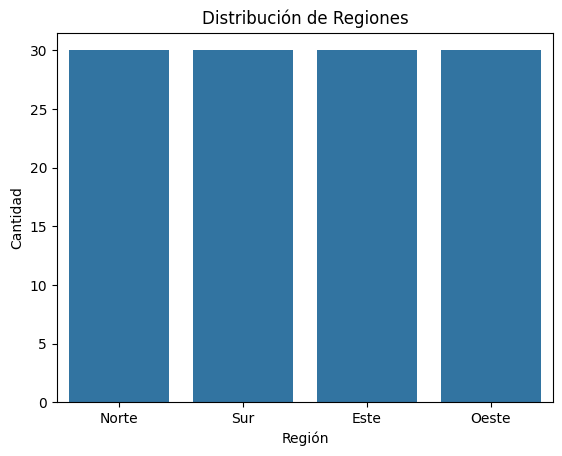

In [71]:
sns.countplot(data=df, x='región')
plt.title('Distribución de Regiones')
plt.xlabel('Región')
plt.ylabel('Cantidad')
plt.show()

Podemos notar que la distribución en el número de registros por región es equitativa.

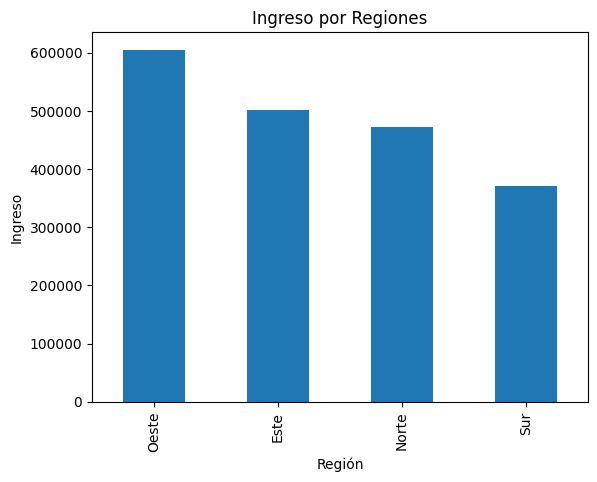

In [72]:
#Visualización de Ingresos por Región
df.groupby('región')['ingresos'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Ingreso por Regiones')
plt.xlabel('Región')
plt.ylabel('Ingreso')
plt.show()

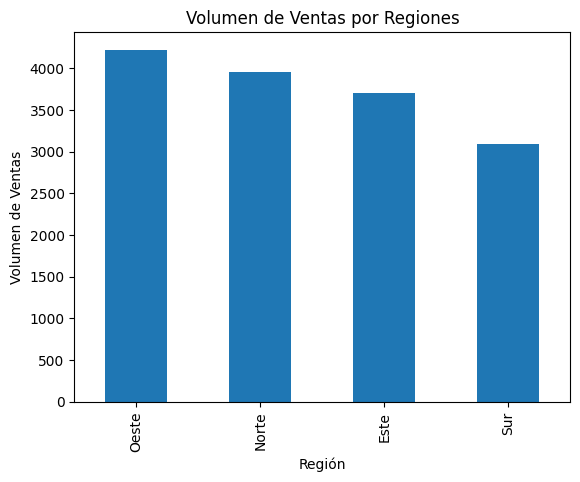

In [73]:
#Visualización de Volumen de Ventas por Región
df.groupby('región')['unidades_vendidas'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Volumen de Ventas por Regiones')
plt.xlabel('Región')
plt.ylabel('Volumen de Ventas')
plt.show()

En ambos gráficos se muestra que las regiones con mayor y menor cantidad de ingresos también comparten ser las regiones con mayor y menor volumen de ventas.

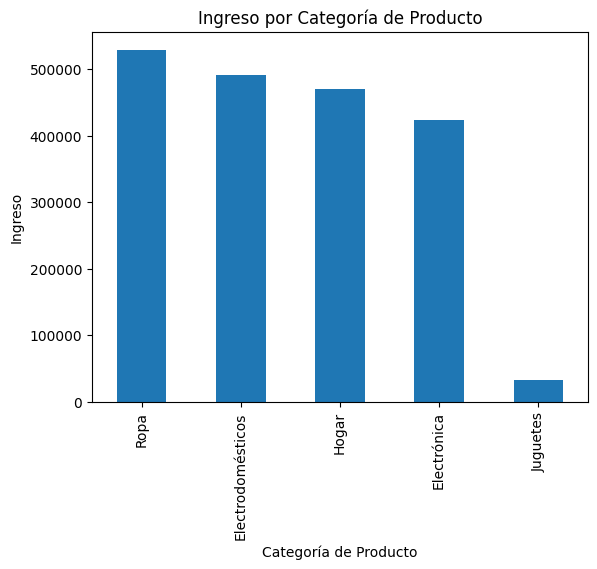

In [74]:
#Visualización Categoría con mayor Ingreso
df.groupby('categoría_de_producto')['ingresos'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Ingreso por Categoría de Producto')
plt.xlabel('Categoría de Producto')
plt.ylabel('Ingreso')
plt.show()

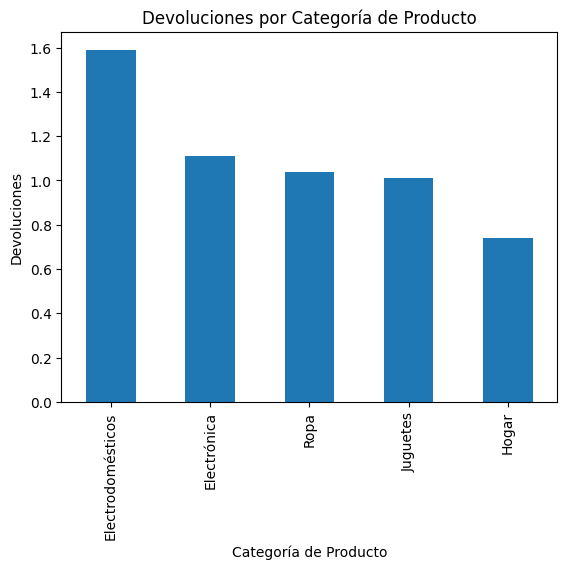

In [75]:
#Visualización de Categoría del producto con mayor número de devoluciones.
df.groupby('categoría_de_producto')['devoluciones'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Devoluciones por Categoría de Producto')
plt.xlabel('Categoría de Producto')
plt.ylabel('Devoluciones')
plt.show()

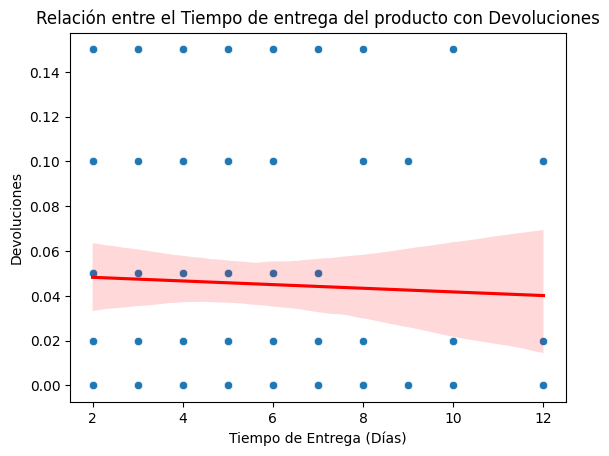

In [76]:
#Búsqueda de relación entre el grado de devoluciones contra el tiempo de entrega.
sns.scatterplot(data=df, x='tiempo_de_entrega_(días)', y='devoluciones')
sns.regplot(data=df, x='tiempo_de_entrega_(días)', y='devoluciones', scatter = False, color = 'red')
plt.title('Relación entre el Tiempo de entrega del producto con Devoluciones')
plt.xlabel('Tiempo de Entrega (Días)')
plt.ylabel('Devoluciones')
plt.show()

El gráfico scatterplot nos ilustra un plano cartesiano con puntos dispersos y no parece que exista una relación lineal clara entre ambas variables.

In [77]:
#Realización de pruebas de correlación
pearson = df['tiempo_de_entrega_(días)'].corr(
    df['devoluciones'],
    method='pearson'
)
spearman = df['tiempo_de_entrega_(días)'].corr(
    df['devoluciones'],
    method='spearman'
)
print('Correlación de Pearson:', pearson)
print('Correlación de Spearman:', spearman)

Correlación de Pearson: -0.03756156035972749
Correlación de Spearman: -0.03845751966006166


El resultado de la pruebas Pearson y Spearman da un total de -0.03. Un valor extremadamente cercano al 0, prácticamente una correlación nula.

In [78]:
#Documento CSV limplio
df.to_csv('df_clean.csv', index=False)

**Paso 4: Resumen Ejecutivo para Stakeholders**

🔍¿Qué región presenta mayor cantidad de ingresos y cuál mayor volumen de ventas?

*  La región del Oeste es la que se presenta como la de mayor cantidad de ingresos para el comercio y, de igual manera, la zona con un mayor volumen de ventas. Para complementar esta información, la zona Sur se presenta como la región con el menor grado de estas métricas.

🔍¿Qué categorías concentran más ingresos y cuáles más reclamos?

*   La categoría con mayor ingreso es la de `Ropa`, mientras que la de mayor porcentaje de devoluciones e `Electrodomésticos`

🔍¿Existe relación entre tiempos de entrega y devoluciones?

*   Teniendo como evidencia visual el scatterpot y como evidencia numérica el resultado de las pruebas Pearson y Spearman, la relación entre estas dos variables es prácticamente nula.  

Enlace para storytelling en Tableau: https://public.tableau.com/views/ProyectoVentasMinoristas/DashboardOverview?:language=es-ES&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link